# Simple Linear Regression

Libraries

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

Generating Data

In [16]:
X, y = make_regression(
    n_samples=100,
    n_features=1,
    noise=10,
    random_state=42
)
data = pd.DataFrame({'X': X.flatten(), 'y': y})


EDA

In [17]:
data.shape

(100, 2)

In [18]:
print("X")
data['X'].head()
print()
data['X'].info()
print()
data['X'].describe()

print("\ny")
print(data['y'].head())
print()
data['y'].info()
print()
data['y'].describe()

X

<class 'pandas.core.series.Series'>
RangeIndex: 100 entries, 0 to 99
Series name: X
Non-Null Count  Dtype  
--------------  -----  
100 non-null    float64
dtypes: float64(1)
memory usage: 932.0 bytes


y
0    50.779929
1   -10.065270
2   -34.918392
3    10.526743
4   -17.738377
Name: y, dtype: float64

<class 'pandas.core.series.Series'>
RangeIndex: 100 entries, 0 to 99
Series name: y
Non-Null Count  Dtype  
--------------  -----  
100 non-null    float64
dtypes: float64(1)
memory usage: 932.0 bytes



count    100.000000
mean      -3.449530
std       41.321720
min     -118.027454
25%      -30.170786
50%       -0.634702
75%       23.478589
max       89.033145
Name: y, dtype: float64

In [19]:
data['X'].isnull().sum(), data['y'].isnull().sum()

(np.int64(0), np.int64(0))

Visualization

<Axes: xlabel='X', ylabel='y'>

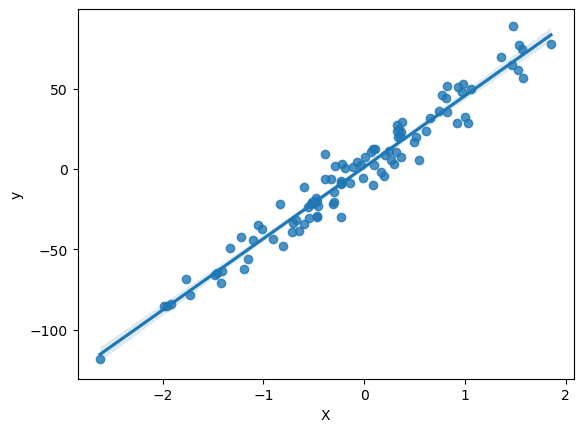

In [20]:
sns.regplot(x=data['X'], y=data['y'])

Model (Class)

In [21]:
class LinearRegression:
    def __init__(self, X, y, intercept: bool = True):
        self.X = np.array(X)
        self.y = np.array(y)
        self.intercept_flag = intercept
        self.slope = None
        self.intercept = None

    def fit(self):
        x_mean = np.mean(self.X)
        y_mean = np.mean(self.y)
        
        # Compute Slope (b1)
        numerator = np.sum((self.X - x_mean) * (self.y - y_mean))
        denominator = np.sum((self.X - x_mean) ** 2)
        self.slope = numerator / denominator
        
        # Compute Intercept (b0)
        if self.intercept_flag:
            self.intercept = y_mean - self.slope * x_mean
        else:
            self.intercept = 0
        
    def predict(self, X_new):
        X_new = np.array(X_new)
        return self.intercept + self.slope * X_new

Training The Model

In [22]:
X_test, X_train, y_test, y_train = train_test_split(data['X'], data['y'], test_size=0.2, random_state=42)
model = LinearRegression(X_train, y_train)
model.fit()
predictions = model.predict(X_test)
print("Predictions:", predictions)

Predictions: [  20.64880848  -39.82277048  -21.44690853   73.2279015    39.54287789
    9.42080294   21.44133518  -58.18635647   50.06831949  -60.58363485
   73.89691241  -23.42990929    0.17434436  -21.49451734  -17.03868715
   34.20449874  -71.56815482   48.51298921   14.10626388  -82.03359615
   14.64133847  -35.15039019   29.51778797   87.9060503     3.7328826
 -111.46025667   10.27505161   70.6698076   -43.99124564   -4.46310958
   75.08307733   19.33942818   28.21190041   41.99973308   32.59904441
   18.53130982  -15.32948881  -59.91460913   -7.99994675   -0.8338955
   20.09801921   -8.45489479  -11.83723467  -17.77485744   -9.27740005
  -79.96549894   -8.09340347  -19.73718369   -4.73524909  -26.76118407
  -18.93897345  -24.84767836   -5.12804293   19.98601794    2.11976781
   -2.94678732   75.7325819    16.96808439  -15.2056023   -83.27734613
  -25.96804223   52.4573738    21.45205327  -47.99779432    9.21066213
   -5.10797371    9.65782885  -41.82354756   46.13938016    4.7283

Evaluation Metrics (Class)

In [23]:
class MeanAbsoluteError:
    def __init__(self, y, y_pred):
        self.y = y
        self.y_pred = y_pred

    def compute(self):
        n = len(self.y)
        if n != len(self.y_pred):
            raise ValueError("y And y_pred Must Have The Same Length")
        
        error_sum = sum(abs(yi - ypi) for yi, ypi in zip(self.y, self.y_pred))
        mae = error_sum / n
        return mae

class MeanSquaredError:
    def __init__(self, y, y_pred):
        self.y = y
        self.y_pred = y_pred

    def compute(self):
        n = len(self.y)
        if n != len(self.y_pred):
            raise ValueError("y And y_pred Must Have The Same Length")
        
        error_sum = sum((yi - ypi)**2 for yi, ypi in zip(self.y, self.y_pred))
        mse = error_sum / n
        return mse

class RootMeanSquaredError:
    def __init__(self, y, y_pred):
        self.y = y
        self.y_pred = y_pred

    def compute(self):
        n = len(self.y)
        if n != len(self.y_pred):
            raise ValueError("y And y_pred Must Have The Same Length")
        
        error_sum = sum((yi - ypi)**2 for yi, ypi in zip(self.y, self.y_pred))
        rmse = np.sqrt(error_sum / n)
        return rmse

class R2_Score:
    def __init__(self, y, y_pred):
        self.y = y
        self.y_pred = y_pred
    
    def compute(self):
        if len(self.y) != len(self.y_pred):
            raise ValueError("y And y_pred Must Have The Same Length")
        
        y_mean = np.mean(self.y)
        
        numerator = sum((yi - ypi)**2 for yi, ypi in zip(self.y, self.y_pred))
        denominator = sum((yi - y_mean)**2 for yi in self.y)

        r2 = 1 - (numerator / denominator)
        return r2

import numpy as np

class Adjusted_R2_Score:
    def __init__(self, y, y_pred, p):
        self.y = y
        self.y_pred = y_pred
        self.n = len(y)
        self.p = p

    def compute(self):
        if len(self.y) != len(self.y_pred):
            raise ValueError("y And y_pred Must Have The Same Length")
        
        y_mean = np.mean(self.y)
        ss_total = sum((yi - y_mean)**2 for yi in self.y)
        ss_residual = sum((yi - ypi)**2 for yi, ypi in zip(self.y, self.y_pred))
        r2 = 1 - (ss_residual / ss_total)
        
        r2_adj = 1 - ((1 - r2) * (self.n - 1) / (self.n - self.p - 1))
        return r2_adj

Evaluation

In [27]:
mae = MeanAbsoluteError(y_test, predictions)
mse = MeanSquaredError(y_test, predictions)
rmse = RootMeanSquaredError(y_test, predictions)
r2_score = R2_Score(y_test, predictions)

print("Mean Absolute Error:", mae.compute())
print("Mean Squared Error:", mse.compute())
print("Root Mean Squared Error:", rmse.compute())
print("R^2 Score:", r2_score.compute())

Mean Absolute Error: 8.119043437161725
Mean Squared Error: 99.92542347602627
Root Mean Squared Error: 9.99627047833472
R^2 Score: 0.9403001225978315
